<a href="https://colab.research.google.com/github/maurocollin/bigdata-saude-niteroi/blob/main/TRAB_PRONTO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Matéria: Tópicos de Big Data em Python
### TEMA:
### Análise de Indicadores de Saúde Municipal Pública e Privada: Previsão de Demandas por Bairro em Niterói-RJ

#### Integrantes:
* Hudson Mata Neves - Matrícula: 202402852175
* Mauro Henrique Collin Ferreira - Matrícula: 202403689601

Nesta primeira etapa centralizamos todas as bibliotecas necessárias e importamos os dados diretamente do repositório do projeto no GitHub. Isso garante que qualquer pessoa consiga rodar o código sem precisar baixar arquivos locais.

In [1]:
# ==============================================================================
# ETAPA 1: SETUP E EXTRAÇÃO DOS DADOS
# ==============================================================================
# Instalação de bibliotecas extras necessárias para os mapas
!pip install geobr folium pyproj -q

import pandas as pd
import numpy as np
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")

print("Iniciando a extração dos dados do GitHub...")

# URL base do repositório
url_base = 'https://raw.githubusercontent.com/maurocollin/bigdata-saude-niteroi/main/'

# Leitura dos arquivos CSV
df_pop = pd.read_csv(f'{url_base}Agregados_por_bairros_basico_BR.csv', sep=';', encoding='latin1', on_bad_lines='skip')
df_ubs = pd.read_csv(f'{url_base}Unidades_Basicas_de_Saude_UBS.csv', encoding='utf-8')
df_hosp = pd.read_csv(f'{url_base}Hospitais.csv', encoding='utf-8')
df_poli = pd.read_csv(f'{url_base}Policlinicas.csv', encoding='utf-8')
df_leitos = pd.read_csv(f'{url_base}CNES_Leitos_Niteroi.csv', encoding='utf-8')

print("✅ Bases carregadas com sucesso!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.0/338.0 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 63.5 MB/s eta 0:00:00
Iniciando a extração dos dados do GitHub...
✅ Bases carregadas com sucesso!


Aqui aplicamos conceitos de Qualidade de Dados. Como as bases vêm de fontes diferentes (IBGE e SUS), os nomes dos bairros estão escritos de formas variadas. Criamos uma função de normalização (maiúsculas e sem acentos) e uma regra de negócio para classificar as unidades em **Públicas** ou **Privadas**.

In [13]:
# ==============================================================================
# ETAPA 2: TRANSFORMAÇÃO, LIMPEZA E REGRAS DE NEGÓCIO
# ==============================================================================

# 1. Função para normalizar strings
def normalizar_bairro(nome):
    if pd.isna(nome): return ''
    nome = str(nome).upper().strip()
    return ''.join(c for c in unicodedata.normalize('NFD', nome) if unicodedata.category(c) != 'Mn')

# Aplicando a normalização nas bases de saúde
df_hosp['BAIRRO_NORM'] = df_hosp['tx_bairro'].apply(normalizar_bairro)
df_poli['BAIRRO_NORM'] = df_poli['bairro'].apply(normalizar_bairro)
df_ubs['BAIRRO_NORM'] = df_ubs['bairro'].apply(normalizar_bairro)

# 2. Classificação Pública e Privada
def categorizar_gestao(nome):
    nome = str(nome).upper()
    palavras_publicas = ['MUNICIPAL', 'ESTADUAL', 'FEDERAL', 'UNIVERSITÁRIO', 'POLÍCIA MILITAR']
    excecoes_publicas = ['HOSPITAL PSIQUIÁTRICO DE JURUJUBA', 'HOSPITAL GETULIO VARGAS FILHO', 'HOSPITAL ORÊNCIO DE FREITAS']

    if any(palavra in nome for palavra in palavras_publicas) or any(exc in nome for exc in excecoes_publicas):
        return 'Pública'
    return 'Privada'

# Aplicando a categorização
df_hosp['Tipo_Unidade'] = df_hosp['tx_nome'].apply(categorizar_gestao)
df_poli['Tipo_Unidade'] = 'Pública' # Policlínicas são públicas
df_ubs['Tipo_Unidade'] = 'Pública'  # UBS são públicas

# 3. Limpando a base de População (IBGE)
df_niteroi = df_pop[df_pop['NM_MUN'] == 'Niterói'].copy()
df_niteroi['BAIRRO_NORM'] = df_niteroi['NM_BAIRRO'].apply(normalizar_bairro)
df_niteroi['POPULACAO'] = pd.to_numeric(df_niteroi['v0001'].astype(str).str.replace(',', '.'), errors='coerce')

print("✅ Padronização e classificação concluídas!")
# display(df_niteroi).head(5)


✅ Padronização e classificação concluídas!


Com os dados limpos, agrupamos a quantidade de unidades de saúde (separadas por tipo) por bairro. Depois, usamos a função `merge` para unir a infraestrutura de saúde com a população, criando nossa **Tabela Analítica Final**.

In [9]:
# ==============================================================================
# ETAPA 3: AGREGAÇÃO (GROUP BY) E CRUZAMENTO (MERGE)
# ==============================================================================

# 1. Consolidar todas as unidades em uma única lista
unidades = []
for _, row in df_hosp.iterrows(): unidades.append({'Bairro': row['BAIRRO_NORM'], 'Tipo': row['Tipo_Unidade']})
for _, row in df_poli.iterrows(): unidades.append({'Bairro': row['BAIRRO_NORM'], 'Tipo': row['Tipo_Unidade']})
for _, row in df_ubs.iterrows():  unidades.append({'Bairro': row['BAIRRO_NORM'], 'Tipo': row['Tipo_Unidade']})

df_unidades = pd.DataFrame(unidades)

# 2. Contar as unidades Públicas e Privadas por Bairro
df_saude_bairro = df_unidades.groupby(['Bairro', 'Tipo']).size().unstack(fill_value=0).reset_index()

# Garantir colunas
for col in ['Privada', 'Pública']:
    if col not in df_saude_bairro.columns: df_saude_bairro[col] = 0

df_saude_bairro['Total_Unidades'] = df_saude_bairro['Pública'] + df_saude_bairro['Privada']

# 3. Cruzamento (Merge) da População com a Saúde
df_pop_resumo = df_niteroi[['BAIRRO_NORM', 'NM_BAIRRO', 'POPULACAO']]
df_final = pd.merge(df_pop_resumo, df_saude_bairro, left_on='BAIRRO_NORM', right_on='Bairro', how='left')

# Tratando os nulos (Bairros sem unidade de saúde viram 0)
df_final[['Privada', 'Pública', 'Total_Unidades']] = df_final[['Privada', 'Pública', 'Total_Unidades']].fillna(0)

print("✅ Tabela Analítica gerada com sucesso! Amostra dos 5 bairros mais populosos:")
display(df_final.sort_values(by='POPULACAO', ascending=False).head()[['NM_BAIRRO', 'POPULACAO', 'Privada', 'Pública', 'Total_Unidades']])

✅ Tabela Analítica gerada com sucesso! Amostra dos 5 bairros mais populosos:


,NM_BAIRRO,POPULACAO,Privada,Pública,Total_Unidades
17,Icaraí,77247,1.0,0.0,1.0
15,Fonseca,46317,2.0,4.0,6.0
37,Santa Rosa,34112,1.0,1.0,2.0
2,Barreto,18699,1.0,5.0,6.0
32,Piratininga,18492,0.0,3.0,3.0


Análise de Sistemas. Criamos a métrica de "Habitantes por Unidade de Saúde" e calculamos o Z-Score. O Z-Score e o método IQR nos mostram estatisticamente o quão longe um bairro está da média da cidade. Utilizamos Gráficos de Histograma e Boxplot para revelar visualmente essas anomalias (superlotação).

Bairros acima do Limite de Superlotação (17132 hab/unidade):


,NM_BAIRRO,POPULACAO,Total_Unidades,Hab_por_Unidade,Z_Score
17,Icaraí,77247,1.0,77247.0,3.643261


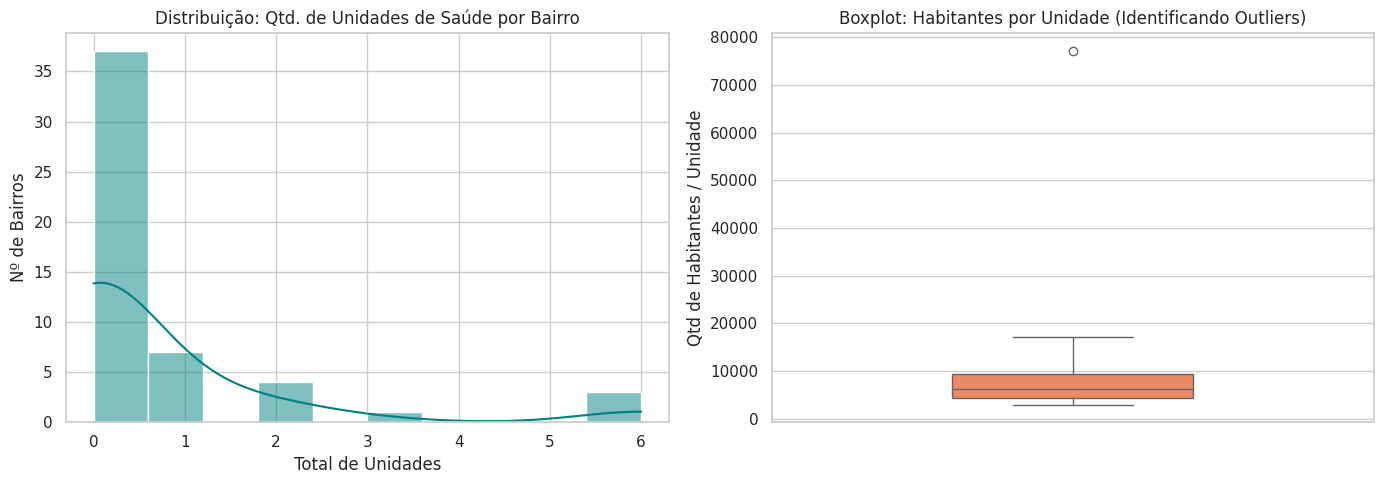

In [4]:
# ==============================================================================
# ETAPA 4: MÉTRICAS, ESTATÍSTICA (Z-SCORE) E GRÁFICOS DE DISTRIBUIÇÃO
# ==============================================================================

# 1. Calculando Habitantes por Unidade Total
df_final['Hab_por_Unidade'] = np.where(df_final['Total_Unidades'] > 0, df_final['POPULACAO'] / df_final['Total_Unidades'], np.nan)

# 2. Estatística Descritiva e Z-Score (apenas bairros com unidade)
df_validos = df_final.dropna(subset=['Hab_por_Unidade']).copy()
df_validos['Z_Score'] = stats.zscore(df_validos['Hab_por_Unidade'])

# Identificação de Outliers matemáticos (Regra do IQR)
Q1 = df_validos['Hab_por_Unidade'].quantile(0.25)
Q3 = df_validos['Hab_por_Unidade'].quantile(0.75)
limite_superior = Q3 + 1.5 * (Q3 - Q1)

print(f"Bairros acima do Limite de Superlotação ({limite_superior:.0f} hab/unidade):")
display(df_validos[df_validos['Hab_por_Unidade'] > limite_superior][['NM_BAIRRO', 'POPULACAO', 'Total_Unidades', 'Hab_por_Unidade', 'Z_Score']])

# 3. GRÁFICOS: Histograma e Boxplot
plt.figure(figsize=(14, 5))

# Histograma
plt.subplot(1, 2, 1)
sns.histplot(df_final['Total_Unidades'], bins=10, kde=True, color='teal')
plt.title('Distribuição: Qtd. de Unidades de Saúde por Bairro', fontsize=12)
plt.xlabel('Total de Unidades')
plt.ylabel('Nº de Bairros')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(y=df_validos['Hab_por_Unidade'], color='coral', width=0.4)
plt.title('Boxplot: Habitantes por Unidade (Identificando Outliers)', fontsize=12)
plt.ylabel('Qtd de Habitantes / Unidade')

plt.tight_layout()
plt.show()

Modelo de Regressão Linear para responder: "A quantidade de unidades de saúde acompanha o tamanho da população?". O cálculo dos **Resíduos** (Diferença entre o Real e o Previsto) nos mostra onde o planejamento urbano falhou: bairros com muita gente, que o modelo previu que deveriam ter unidades, mas na realidade possuem forte déficit.:

In [5]:
# ==============================================================================
# ETAPA 5: REGRESSÃO LINEAR INTERATIVA (DEMANDA X OFERTA)
# ==============================================================================

# 1. Preparação dos dados para a regressão
df_reg = df_final[df_final['POPULACAO'] > 0].copy()

X = df_reg[['POPULACAO']]
y = df_reg['Total_Unidades']

# 2. Treinando o modelo
modelo = LinearRegression().fit(X, y)
df_reg['PREDICAO'] = modelo.predict(X)
df_reg['RESIDUO'] = df_reg['Total_Unidades'] - df_reg['PREDICAO']

r2 = r2_score(y, df_reg['PREDICAO'])

# Bairros onde o modelo mais errou (Maior Déficit = Resíduo Negativo)
df_tendencia = df_reg.sort_values(by='POPULACAO')

# 3. Gráfico Interativo com Plotly
fig = px.scatter(
    df_reg,
    x='POPULACAO', y='Total_Unidades',
    color='RESIDUO',
    text='NM_BAIRRO', hover_name='NM_BAIRRO',
    hover_data={'POPULACAO': ':,.0f', 'Total_Unidades': True, 'RESIDUO': ':.2f'},
    title=f'<b>Niterói: Regressão População vs Infraestrutura (R²: {r2:.4f})</b><br><sup>Bairros em tons vermelhos indicam forte Déficit (Realidade < Previsto)</sup>',
    labels={'POPULACAO': 'População do Bairro', 'Total_Unidades': 'Unidades Reais', 'RESIDUO': 'Resíduo (Déficit)'},
    color_continuous_scale=px.colors.sequential.Reds_r,
    template='plotly_dark'
)

# Adicionando a linha de tendência
fig.add_trace(go.Scatter(x=df_tendencia['POPULACAO'], y=df_tendencia['PREDICAO'], mode='lines', name='Tendência', line=dict(color='cyan', width=2, dash='dot')))

fig.update_traces(textposition='top center', marker=dict(size=12, opacity=0.8))
fig.update_layout(height=650)
fig.show()

Para trazer uma perspectiva geográfica ao nosso problema de Big Data, utilizamos a biblioteca `Folium` aliada à conversão de coordenadas (`PyProj`). O mapa abaixo exibe de forma interativa a exata localização geográfica dos Hospitais, diferenciando a rede Pública (Vermelho) da rede Privada (Azul).

In [6]:
# ==============================================================================
# ETAPA 6: VISUALIZAÇÃO ESPACIAL - MAPA DE HOSPITAIS EM NITERÓI
# ==============================================================================
import folium
from pyproj import Transformer

print("Gerando Mapa Interativo Espacial...")

# Transformador de coordenadas UTM 23S para Lat/Lon
transformer = Transformer.from_crs("epsg:31983", "epsg:4326", always_xy=True)

df_mapa = df_hosp.dropna(subset=['X', 'Y', 'tx_nome', 'tx_bairro']).copy()

# Conversão
def converter_coord(x, y):
    try:
        lon, lat = transformer.transform(x, y)
        return lat, lon
    except: return None, None

df_mapa['Lat'], df_mapa['Lon'] = zip(*df_mapa.apply(lambda r: converter_coord(r['X'], r['Y']), axis=1))

# Construção do Mapa
mapa_niteroi = folium.Map(location=[-22.883, -43.106], zoom_start=13, tiles='OpenStreetMap')

for _, row in df_mapa.iterrows():
    if pd.isna(row['Lat']): continue
    popup_text = f"<b>{row['tx_nome']}</b><br>Bairro: {row['tx_bairro']}<br>Gestão: {row['Tipo_Unidade']}"
    cor = 'red' if row['Tipo_Unidade'] == 'Pública' else 'blue'

    folium.Marker(
        location=[row['Lat'], row['Lon']],
        popup=folium.Popup(popup_text, max_width=300),
        icon=folium.Icon(color=cor, icon='plus', prefix='fa')
    ).add_to(mapa_niteroi)

display(mapa_niteroi)

Gerando Mapa Interativo Espacial...


Além dos pontos, precisamos entender as manchas de cobertura. Cruzamos os dados com a malha territorial oficial do IPEA (`geobr`) para gerar um Mapa Coroplético. Nele classificamos as zonas de assistência: Desertos Assistenciais, áreas exclusivas do SUS, áreas exclusivamente privadas e áreas de cobertura Mista.

In [7]:
# ==============================================================================
# ETAPA 7: MAPA COROPLÉTICO - ZONAS DE ASSISTÊNCIA DE SAÚDE
# ==============================================================================
import geobr

print("Baixando a malha geográfica de Niterói (IPEA)...")

# Malha territorial de Niterói
malha_niteroi = geobr.read_neighborhood(year=2022)
malha_niteroi = malha_niteroi[malha_niteroi['code_muni'] == 3303302.0].copy()

# Merge Espacial (Geometria + Nossos Dados)
malha_niteroi['BAIRRO_MAPA'] = malha_niteroi['name_neighborhood'].apply(normalizar_bairro)
mapa_completo = malha_niteroi.merge(df_final, left_on='BAIRRO_MAPA', right_on='BAIRRO_NORM', how='left')
mapa_completo[['POPULACAO', 'Pública', 'Privada']] = mapa_completo[['POPULACAO', 'Pública', 'Privada']].fillna(0)

# Lógica de Categorização Assistencial
def definir_zona(row):
    sus, priv = row['Pública'], row['Privada']
    if sus == 0 and priv == 0: return '#636e72', 'Deserto Assistencial'
    if sus > 0 and priv == 0:  return '#2ecc71', 'Apenas Pública (SUS)'
    if sus == 0 and priv > 0:  return '#3498db', 'Apenas Privada'
    return '#9b59b6', 'Mista (Pública e Privada)'

mapa_completo[['cor', 'categoria']] = mapa_completo.apply(lambda r: pd.Series(definir_zona(r)), axis=1)

# Montando o mapa base
m_coro = folium.Map(location=[-22.90, -43.08], zoom_start=12, tiles='cartodbpositron')

# Legenda customizada
legenda_html = '''
     <div style="position: fixed; bottom: 50px; left: 50px; width: 230px; height: 130px;
                 background-color: white; border:2px solid grey; z-index:9999; font-size:12px; padding: 10px;">
     <b>Zonas de Assistência:</b><br><br>
     <i style="background:#636e72;width:14px;height:14px;display:inline-block;border-radius:50%;"></i> Deserto Assistencial<br>
     <i style="background:#2ecc71;width:14px;height:14px;display:inline-block;border-radius:50%;"></i> Apenas Pública (SUS)<br>
     <i style="background:#3498db;width:14px;height:14px;display:inline-block;border-radius:50%;"></i> Apenas Privada<br>
     <i style="background:#9b59b6;width:14px;height:14px;display:inline-block;border-radius:50%;"></i> Mista
     </div>
'''
m_coro.get_root().html.add_child(folium.Element(legenda_html))

# Camada do GeoJson
folium.GeoJson(
    mapa_completo,
    style_function=lambda x: {'fillColor': x['properties']['cor'], 'color': '#2c3e50', 'weight': 1, 'fillOpacity': 0.75},
    highlight_function=lambda x: {'weight': 3, 'fillOpacity': 0.9, 'color': 'black'},
    tooltip=folium.GeoJsonTooltip(
        fields=['name_neighborhood', 'POPULACAO', 'categoria', 'Pública', 'Privada'],
        aliases=['Bairro:', 'População:', 'Status:', 'Unid. Públicas:', 'Unid. Privadas:']
    )
).add_to(m_coro)

display(m_coro)

Baixando a malha geográfica de Niterói (IPEA)...


Por fim, realizamos a Análise de Capacidade Hospitalar do município comparando o total de leitos com o Indicador Global da OMS (Organização Mundial da Saúde), que recomenda a meta de **3 a 5 leitos por mil habitantes**. Esse cruzamento avalia se a macro-estrutura da cidade é capaz de suportar sua população em um cenário geral.

--- RAIO-X DA CAPACIDADE HOSPITALAR DE NITERÓI ---

População Total: 481.749
Total de Leitos na cidade: 3.136
➔ INDICADOR OMS ALCANÇADO: 6.51 leitos para cada 1.000 habitantes.

STATUS: ✅ DENTRO/ACIMA da meta recomendada pela Organização Mundial da Saúde (3 a 5)


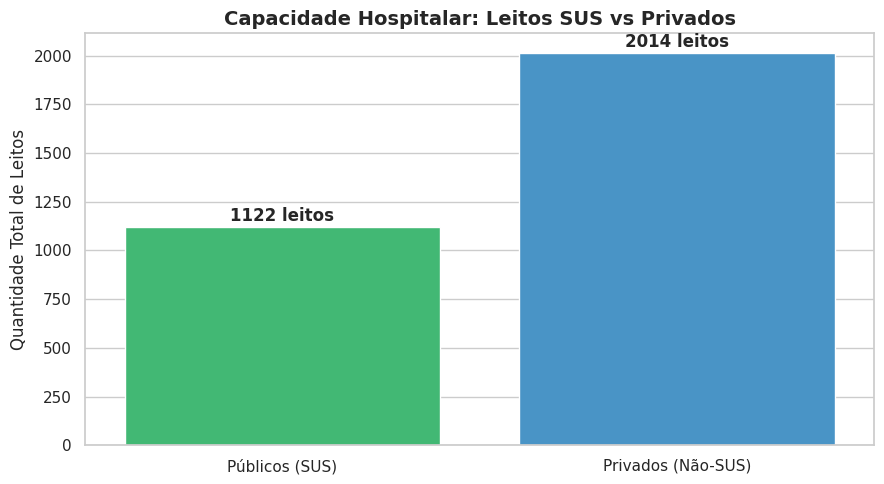

In [14]:
# ==============================================================================
# ETAPA 8: ANÁLISE DE CAPACIDADE HOSPITALAR E INDICADOR DA OMS
# ==============================================================================

print("--- RAIO-X DA CAPACIDADE HOSPITALAR DE NITERÓI ---\n")

# 1. Tratamento numérico dos dados do CNES (Leitos)
df_leitos['QT_SUS'] = pd.to_numeric(df_leitos['QT_SUS'], errors='coerce').fillna(0)
df_leitos['QT_NSUS'] = pd.to_numeric(df_leitos['QT_NSUS'], errors='coerce').fillna(0)

# 2. Cálculos Totais
total_sus = df_leitos['QT_SUS'].sum()
total_privado = df_leitos['QT_NSUS'].sum()
total_leitos = total_sus + total_privado
populacao_total = df_niteroi['POPULACAO'].sum()

# 3. Métrica Ouro (Taxa OMS por mil habitantes)
taxa_oms = (total_leitos / populacao_total) * 1000

print(f"População Total: {int(populacao_total):,}".replace(',', '.'))
print(f"Total de Leitos na cidade: {int(total_leitos):,}".replace(',', '.'))
print(f"➔ INDICADOR OMS ALCANÇADO: {taxa_oms:.2f} leitos para cada 1.000 habitantes.\n")

if taxa_oms >= 3:
    print("STATUS: ✅ DENTRO/ACIMA da meta recomendada pela Organização Mundial da Saúde (3 a 5)")
else:
    print("STATUS: ❌ ABAIXO da meta recomendada pela Organização Mundial da Saúde (3 a 5)")

# 4. Gráfico Final
plt.figure(figsize=(9, 5))
# Passar 'x' para 'hue' e usar legend=False para adequação ao novo padrão do Seaborn
ax = sns.barplot(
    x=['Públicos (SUS)', 'Privados (Não-SUS)'],
    y=[total_sus, total_privado],
    hue=['Públicos (SUS)', 'Privados (Não-SUS)'],
    palette=['#2ecc71', '#3498db'],
    legend=False
)

plt.title('Capacidade Hospitalar: Leitos SUS vs Privados', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade Total de Leitos', fontsize=12)

# Adicionando os valores em cima das barras
for i, valor in enumerate([total_sus, total_privado]):
    plt.text(i, valor + 30, f'{int(valor)} leitos', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()